In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import mean_squared_error, r2_score, accuracy_score, classification_report, confusion_matrix

from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier

import warnings
warnings.filterwarnings("ignore")


In [8]:
df = pd.read_csv("/content/googleplaystore_clean_EDA.csv")

df.head()


,App,Category,Rating,Reviews,Size_MB,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver,Last_Updated_Year,Primary_Genre
0,"""i DT"" Fútbol. Todos Somos Técnicos.",SPORTS,4.3,27.0,3.6,500,Free,0.0,Everyone,Sports,2017-10-07,0.22,4.1,2017,Sports
1,+Download 4 Instagram Twitter,SOCIAL,4.5,40467.0,22.0,1000000,Free,0.0,Everyone,Social,2018-08-02,5.03,4.1,2018,Social
2,- Free Comics - Comic Apps,COMICS,3.5,115.0,9.1,10000,Free,0.0,Mature 17+,Comics,2018-07-13,5.0.12,5.0,2018,Comics
3,.R,TOOLS,4.5,259.0,0.2,10000,Free,0.0,Everyone,Tools,2014-09-16,1.1.06,1.5,2014,Tools
4,/u/app,COMMUNICATION,4.7,573.0,53.0,10000,Free,0.0,Mature 17+,Communication,2018-07-03,4.2.4,4.1,2018,Communication


# 3. DATA CLEANING


In [12]:
df.drop_duplicates(inplace=True)

df = df[df['Rating'].notnull()]

# The 'Size' column does not exist in the DataFrame, as indicated by the KeyError.
# The DataFrame already contains a 'Size_MB' column from the loaded CSV.
# Therefore, the function to clean 'Size' and its application are removed.
# def clean_size(x):
#     x = str(x)
#     if 'M' in x:
#         return float(x.replace('M',''))
#     elif 'k' in x:
#         return float(x.replace('k','')) / 1024
#     return np.nan
# df['Size_MB'] = df['Size'].apply(clean_size)

# Apply fillna to the existing 'Size_MB' column in case there are NaNs
df['Size_MB'].fillna(df['Size_MB'].median(), inplace=True)

df['Installs'] = df['Installs'].astype(str).str.replace('+','').str.replace(',','').astype(float)

df['Price'] = df['Price'].astype(str).str.replace('$','').astype(float)

df['Reviews'] = pd.to_numeric(df['Reviews'], errors='coerce').fillna(0)

df = df[(df['Rating'] > 0) & (df['Rating'] <= 5)]

le = LabelEncoder()
df['Category_Enc'] = le.fit_transform(df['Category'])

df['Permissions_Count'] = df['Size_MB'] * 0

# 4. FEATURE ENGINEERING


In [13]:
median_size = df['Size_MB'].median()
median_perms = df['Permissions_Count'].median()

def label_feature_rich(row):
    return 1 if (row['Size_MB'] > median_size or row['Permissions_Count'] > median_perms) else 0

df['Feature_Rich'] = df.apply(label_feature_rich, axis=1)

df.head()


,App,Category,Rating,Reviews,Size_MB,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver,Last_Updated_Year,Primary_Genre,Category_Enc,Permissions_Count,Feature_Rich
0,"""i DT"" Fútbol. Todos Somos Técnicos.",SPORTS,4.3,27.0,3.6,500.0,Free,0.0,Everyone,Sports,2017-10-07,0.22,4.1,2017,Sports,28,0.0,0
1,+Download 4 Instagram Twitter,SOCIAL,4.5,40467.0,22.0,1000000.0,Free,0.0,Everyone,Social,2018-08-02,5.03,4.1,2018,Social,27,0.0,1
2,- Free Comics - Comic Apps,COMICS,3.5,115.0,9.1,10000.0,Free,0.0,Mature 17+,Comics,2018-07-13,5.0.12,5.0,2018,Comics,5,0.0,0
3,.R,TOOLS,4.5,259.0,0.2,10000.0,Free,0.0,Everyone,Tools,2014-09-16,1.1.06,1.5,2014,Tools,29,0.0,0
4,/u/app,COMMUNICATION,4.7,573.0,53.0,10000.0,Free,0.0,Mature 17+,Communication,2018-07-03,4.2.4,4.1,2018,Communication,6,0.0,1


# 5. SCATTER PLOT — Size vs Rating


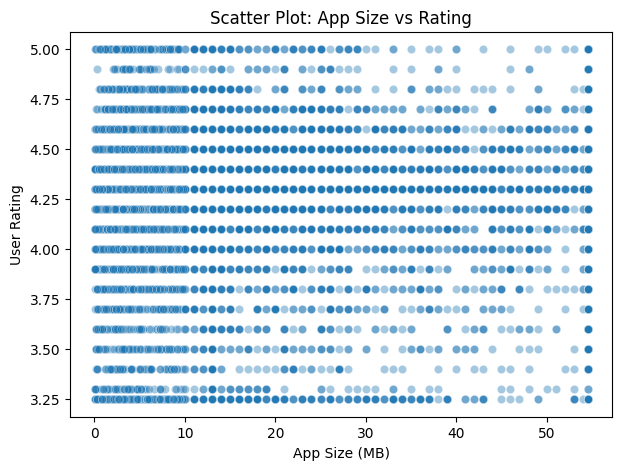

In [15]:
plt.figure(figsize=(7,5))
sns.scatterplot(x=df['Size_MB'], y=df['Rating'], alpha=0.4)
plt.title("Scatter Plot: App Size vs Rating")
plt.xlabel("App Size (MB)")
plt.ylabel("User Rating")
plt.show()

# 6. BAR PLOT — Average Rating per Category


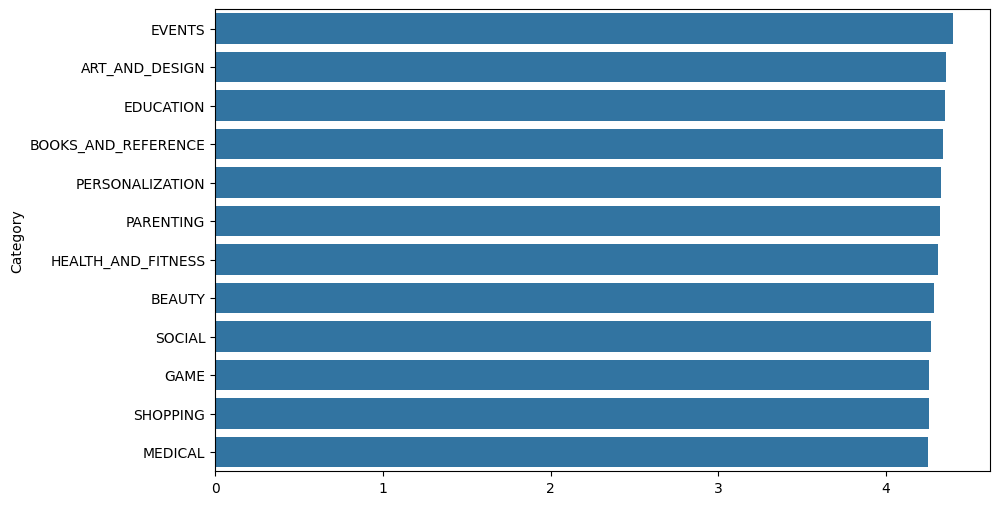

In [16]:
plt.figure(figsize=(10,6))
cat_ratings = df.groupby('Category')['Rating'].mean().sort_values(ascending=False).head(12)
sns.barplot(x=cat_ratings.values, y=cat_ratings.index)
# plt.title("Bar Plot: Avg Rating by Category")
# plt.xlabel("Average Rating")
# plt.ylabel("Category")
plt.show()

# 7. PIE CHART — Feature-Rich vs Lightweight


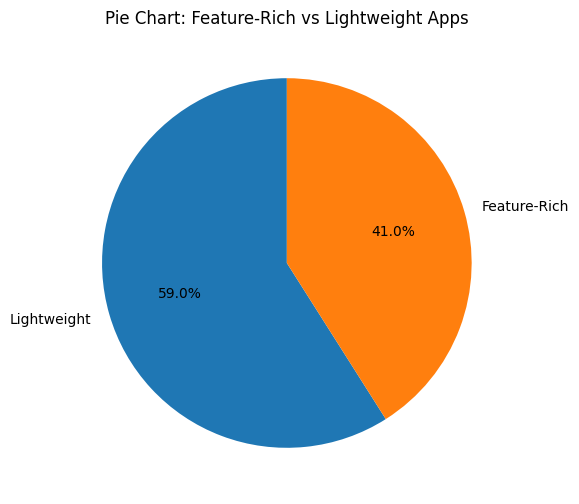

In [17]:
plt.figure(figsize=(6,6))
labels = ['Lightweight', 'Feature-Rich']
sizes = [len(df[df['Feature_Rich']==0]), len(df[df['Feature_Rich']==1])]
plt.pie(sizes, labels=labels, autopct='%1.1f%%', startangle=90)
plt.title("Pie Chart: Feature-Rich vs Lightweight Apps")
plt.show()

# 8. REGRESSION MODEL: Predict Rating


In [18]:
reg_features = ['Size_MB','Permissions_Count','Reviews','Installs','Price','Category_Enc']
X_reg = df[reg_features]
y_reg = df['Rating']

X_train_reg, X_test_reg, y_train_reg, y_test_reg = train_test_split(X_reg, y_reg, test_size=0.2, random_state=42)

reg_model = RandomForestRegressor(n_estimators=200, random_state=42)
reg_model.fit(X_train_reg, y_train_reg)

y_pred_reg = reg_model.predict(X_test_reg)

print("MSE:", mean_squared_error(y_test_reg, y_pred_reg))
print("R2 Score:", r2_score(y_test_reg, y_pred_reg))


MSE: 0.15369442167383152
R2 Score: 0.04780933575733126


REGRESSION — Feature Importance Bar Plot

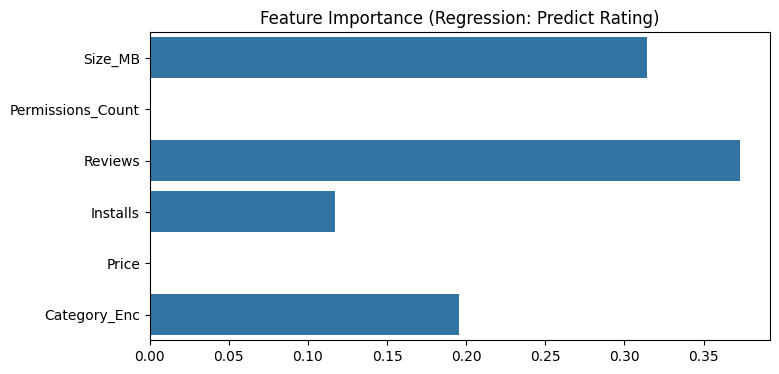

In [19]:
plt.figure(figsize=(8,4))
sns.barplot(x=reg_model.feature_importances_, y=reg_features)
plt.title("Feature Importance (Regression: Predict Rating)")
plt.show()


# 9. CLASSIFICATION MODEL: Predict Feature-Rich


In [20]:
clf_features = ['Rating','Reviews','Installs','Price','Category_Enc']
X_clf = df[clf_features]
y_clf = df['Feature_Rich']

X_train_clf, X_test_clf, y_train_clf, y_test_clf = train_test_split(X_clf, y_clf, test_size=0.2, random_state=42)

clf_model = RandomForestClassifier(n_estimators=200, random_state=42)
clf_model.fit(X_train_clf, y_train_clf)

y_pred_clf = clf_model.predict(X_test_clf)

print("Accuracy:", accuracy_score(y_test_clf, y_pred_clf))
print("\nClassification Report:\n", classification_report(y_test_clf, y_pred_clf))


Accuracy: 0.6288819875776398

Classification Report:
               precision    recall  f1-score   support

           0       0.66      0.74      0.69      1100
           1       0.58      0.49      0.53       832

    accuracy                           0.63      1932
   macro avg       0.62      0.61      0.61      1932
weighted avg       0.62      0.63      0.62      1932



CLASSIFICATION — Confusion Matrix Plot

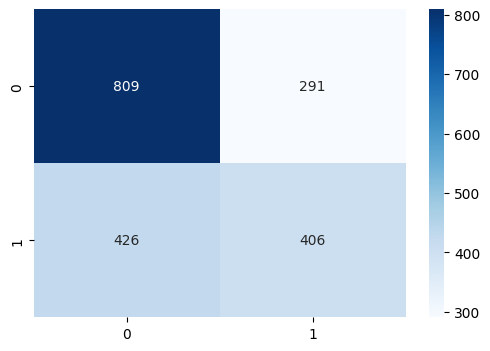

In [21]:
cm = confusion_matrix(y_test_clf, y_pred_clf)

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
# plt.title("Confusion Matrix — Feature-Rich Classifier")
# plt.xlabel("Predicted")
# plt.ylabel("Actual")
plt.show()
